  Energy Dispatch Optimization — POSOCO NR Data
  Date     : 2024-03-26 (Northern Region)
  Demand   : 98.6 – 150.0 kWh (scaled)
  Real NR  : 32946 – 50141 MW

  Solver status : Optimal

=== Hourly Dispatch Results ===
 hour     demand     solar  wind       grid    charge  discharge   soc
    0 103.491336  0.000000  26.0  77.491336  0.000000        0.0   0.0
    1 100.499155  0.000000  39.0 111.499160 50.000000        0.0  47.5
    2  98.559862  0.000000  48.0 100.559860 50.000000        0.0  95.0
    3  99.160542  0.000000  34.0 115.160540 50.000000        0.0 142.5
    4 104.022641  0.000000  30.0 124.022640 50.000000        0.0 190.0
    5 113.152860  0.000000  27.0  96.679176 10.526316        0.0 200.0
    6 123.269165  0.000000  48.0  75.269165  0.000000        0.0 200.0
    7 129.673515 15.529143  40.0  74.144372  0.000000        0.0 200.0
    8 133.522784 30.000000  26.0  30.022784  0.000000       47.5 152.5
    9 141.595030 42.426407  45.0 104.168620 50.000000        0.0 200.0


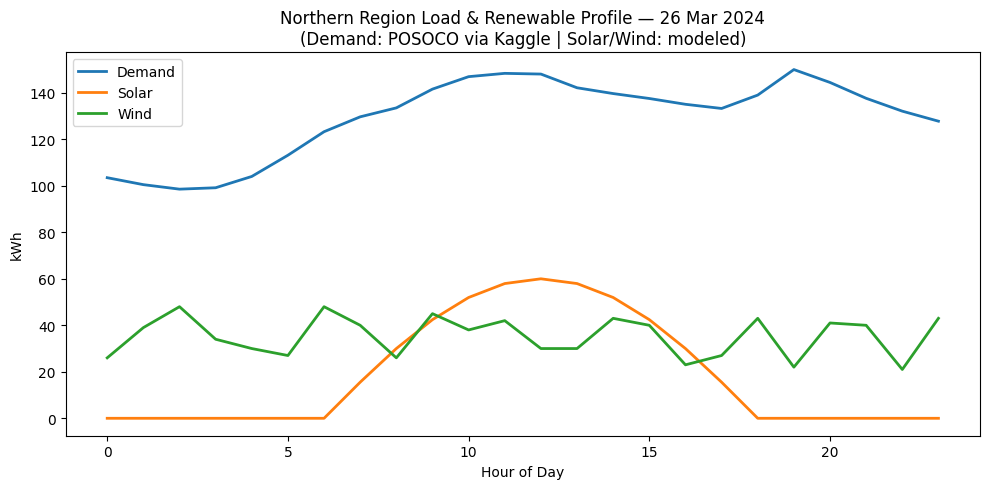

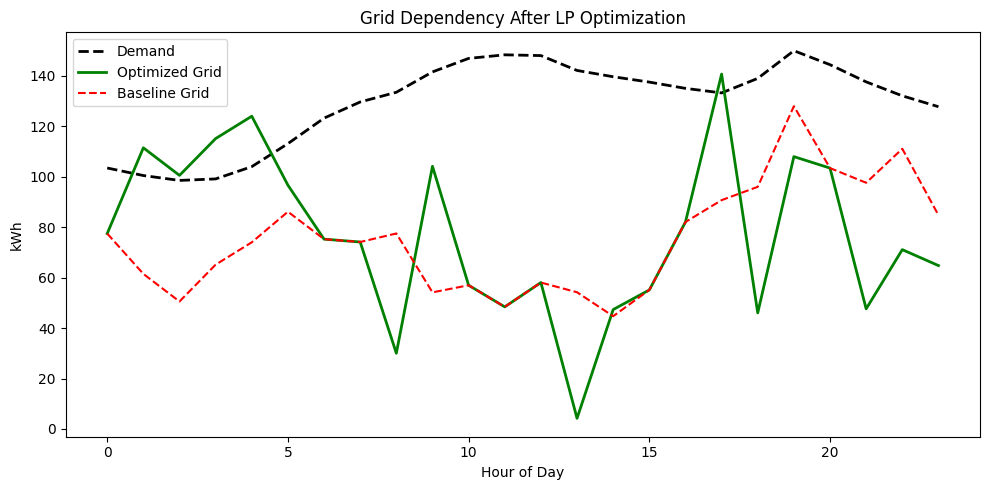

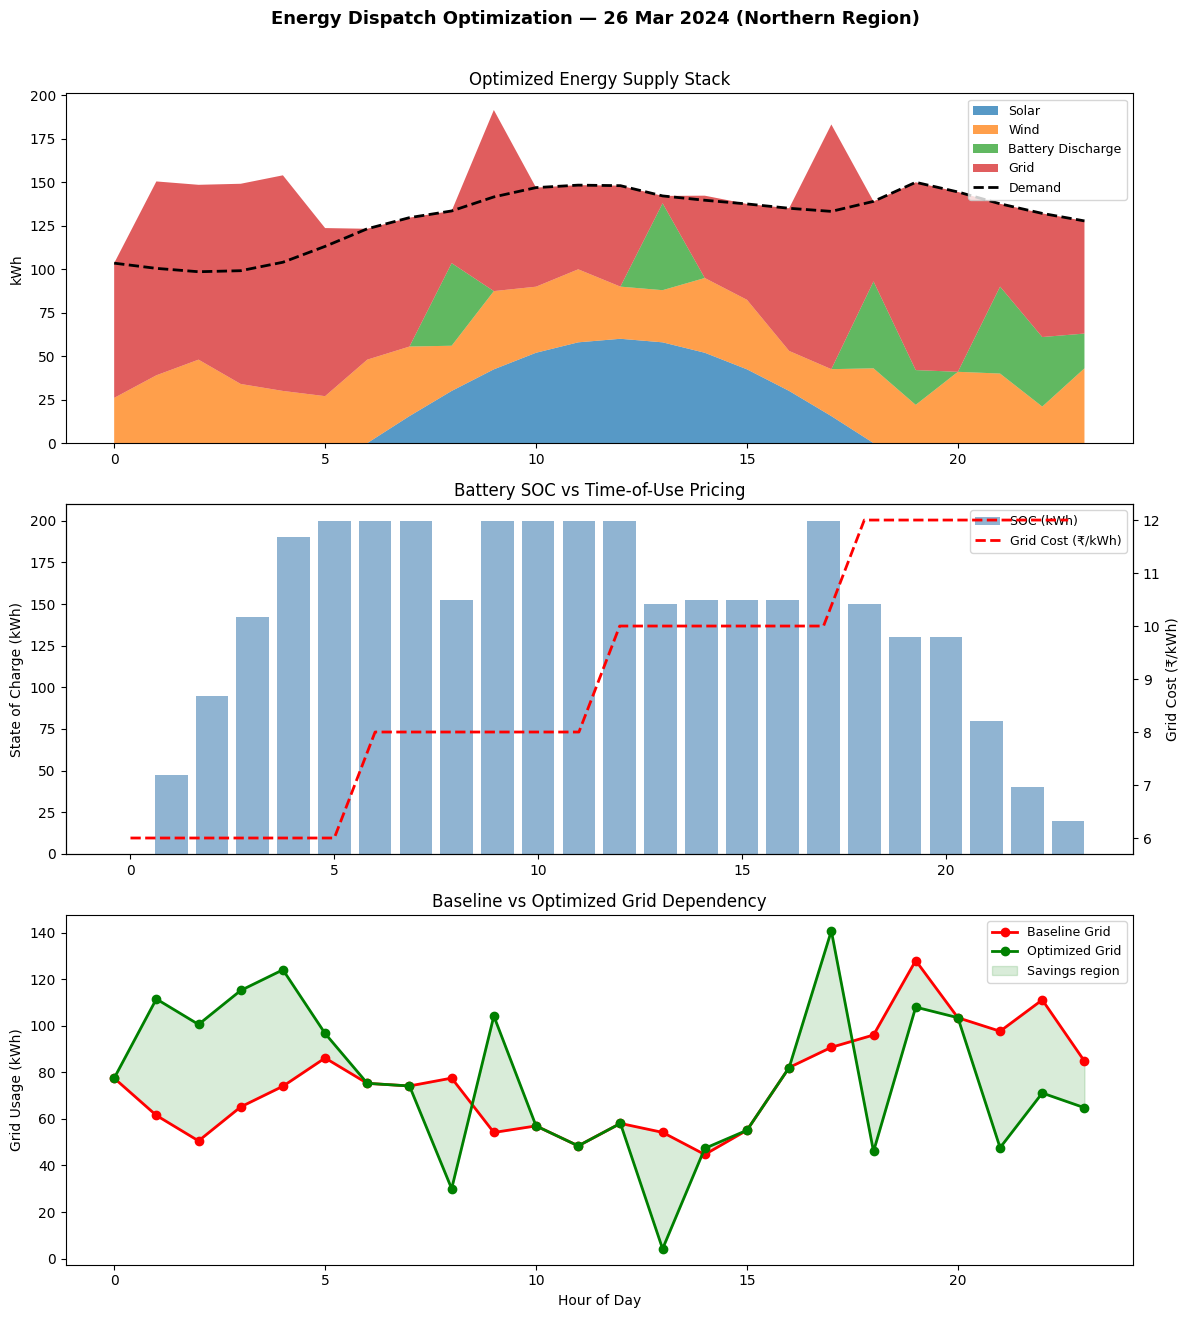

  Saved: renewable_supply_profile.png
  Saved: grid_dependency.png
  Saved: energy_dispatch_results.png

Done.


In [8]:
"""
Energy Dispatch Optimization — Linear Programming
==================================================
Minimizes grid cost and carbon emission penalties over a 24-hour
dispatch window across solar, wind, battery storage, and grid sources.

Author  : Aditya Singh
Affil.  : M.Sc. Applied Physics, Amity University Uttar Pradesh, Lucknow
Date    : 2026

Dataset : Kaggle — "Hourly Load India / Electrical Load Forecasting"
          by Shubham Vashisht
          https://www.kaggle.com/datasets/shubhamvashisht/hourly-load-india-electrical-load-forecasting
          Underlying data: POSOCO (Power System Operation Corporation of India)
          Coverage: 2019-01-01 to 2024-04-30, hourly resolution

Dependencies: numpy, pandas, matplotlib, pulp, openpyxl
"""

# ── Imports ────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pulp import (
    LpProblem, LpMinimize, LpVariable, lpSum,
    LpStatus, PULP_CBC_CMD
)

# ── Configuration ──────────────────────────────────────────────────────────────
DATA_PATH = "data/hourlyLoadDataIndia.xlsx"
SELECTED_DATE    = "2024-03-26"
DEMAND_PEAK_KWH  = 150.0       # normalize NR demand to this peak (kWh)

BATTERY_CAPACITY    = 200.0    # kWh
MAX_CHARGE_RATE     = 50.0     # kWh/hr
MAX_DISCHARGE_RATE  = 50.0     # kWh/hr
EFFICIENCY          = 0.95     # round-trip charging efficiency
MIN_FINAL_SOC       = 20.0     # minimum SOC at end of day (kWh)

EMISSION_WEIGHT     = 8        # ₹ per kg CO₂ (emission penalty weight)

np.random.seed(42)
hours = np.arange(24)


# ── 1. Load & Prepare Data ─────────────────────────────────────────────────────
df_raw   = pd.read_excel(DATA_PATH, parse_dates=["datetime"])
day_data = df_raw[df_raw["datetime"].dt.date.astype(str) == SELECTED_DATE].copy()
day_data = day_data.reset_index(drop=True)

nr_demand_mw = day_data["Northen Region Hourly Demand"].values   # 24 real MW values
SCALE        = DEMAND_PEAK_KWH / nr_demand_mw.max()
demand_real  = nr_demand_mw * SCALE

print("=" * 60)
print("  Energy Dispatch Optimization — POSOCO NR Data")
print("=" * 60)
print(f"  Date     : {SELECTED_DATE} (Northern Region)")
print(f"  Demand   : {demand_real.min():.1f} – {demand_real.max():.1f} kWh (scaled)")
print(f"  Real NR  : {nr_demand_mw.min():.0f} – {nr_demand_mw.max():.0f} MW")
print("=" * 60)

# Solar: sinusoidal irradiance envelope for North India (lat ~28°N)
# No hourly solar in dataset; consistent with CEA/MNRE documentation
solar = np.maximum(0, 60 * np.sin((hours - 6) / 12 * np.pi))

# Wind: uniform random within realistic NR microgrid range (20–50 kWh/hr)
wind = np.random.randint(20, 50, 24).astype(float)

# Grid cost: DERC Time-of-Use tariff tiers (₹/kWh)
grid_cost = [6 if h < 6 else 8 if h < 12 else 10 if h < 18 else 12
             for h in hours]

# Emission factor: CEA CO₂ Baseline Database 2023-24, Northern Region
# Range: 0.70 – 0.95 kg CO₂/kWh
emission_factor = np.random.uniform(0.70, 0.95, 24)

data = pd.DataFrame({
    "hour":            hours,
    "demand":          demand_real,
    "solar":           solar,
    "wind":            wind,
    "grid_cost":       grid_cost,
    "emission_factor": emission_factor,
})


# ── 2. Baseline (No Battery) ───────────────────────────────────────────────────
baseline = data[["hour", "demand", "solar", "wind"]].copy()
baseline["renewable_used"] = baseline["solar"] + baseline["wind"]
baseline["grid"]      = (baseline["demand"] - baseline["renewable_used"]).clip(lower=0)
baseline["cost"]      = baseline["grid"] * data["grid_cost"]
baseline["emissions"] = baseline["grid"] * data["emission_factor"] * EMISSION_WEIGHT


# ── 3. LP Optimization ─────────────────────────────────────────────────────────
model = LpProblem("Energy_Dispatch", LpMinimize)

solar_var  = LpVariable.dicts("solar",     data.index, lowBound=0)
wind_var   = LpVariable.dicts("wind",      data.index, lowBound=0)
grid_var   = LpVariable.dicts("grid",      data.index, lowBound=0)
charge     = LpVariable.dicts("charge",    data.index, lowBound=0)
discharge  = LpVariable.dicts("discharge", data.index, lowBound=0)
soc        = LpVariable.dicts("soc",       data.index, lowBound=0)

# Objective: minimize weighted grid cost + emission penalty
model += lpSum(
    grid_var[i] * data.loc[i, "grid_cost"] +
    grid_var[i] * data.loc[i, "emission_factor"] * EMISSION_WEIGHT
    for i in data.index
)

# Constraints
for i in data.index:
    # Power balance
    model += solar_var[i] + wind_var[i] + grid_var[i] + discharge[i] == \
             data.loc[i, "demand"] + charge[i]
    # Renewable availability caps
    model += solar_var[i] <= data.loc[i, "solar"]
    model += wind_var[i]  <= data.loc[i, "wind"]
    # Battery rate limits
    model += charge[i]    <= MAX_CHARGE_RATE
    model += discharge[i] <= MAX_DISCHARGE_RATE
    model += discharge[i] <= soc[i]

# Initial and dynamic SOC
model += soc[0] == 0
for i in data.index:
    if i > 0:
        model += soc[i] == soc[i-1] + charge[i] * EFFICIENCY - discharge[i]
        model += soc[i] <= BATTERY_CAPACITY

# Minimum end-of-day reserve
model += soc[23] >= MIN_FINAL_SOC

# Solve
model.solve(PULP_CBC_CMD(msg=0))
print(f"\n  Solver status : {LpStatus[model.status]}\n")


# ── 4. Results ─────────────────────────────────────────────────────────────────
results = pd.DataFrame({
    "hour":      data["hour"],
    "demand":    data["demand"],
    "solar":     [solar_var[i].varValue  for i in data.index],
    "wind":      [wind_var[i].varValue   for i in data.index],
    "grid":      [grid_var[i].varValue   for i in data.index],
    "charge":    [charge[i].varValue     for i in data.index],
    "discharge": [discharge[i].varValue  for i in data.index],
    "soc":       [soc[i].varValue        for i in data.index],
})

print("=== Hourly Dispatch Results ===")
print(results.to_string(index=False))
print("\n=== Summary Statistics ===")
print(results.describe().round(2))


# ── 5. Comparison ──────────────────────────────────────────────────────────────
base_grid_kwh  = baseline["grid"].sum()
opt_grid_kwh   = results["grid"].sum()
base_cost      = baseline["cost"].sum()
opt_cost       = (results["grid"] * data["grid_cost"]).sum()
base_em        = baseline["emissions"].sum()
opt_em         = (results["grid"] * data["emission_factor"] * EMISSION_WEIGHT).sum()
base_peak      = baseline["grid"][18:].sum()
opt_peak       = results["grid"][18:].sum()

print("\n=== Baseline vs Optimized ===")
print(f"{'Metric':<30} {'Baseline':>12} {'Optimized':>12} {'Change':>10}")
print("-" * 66)
print(f"{'Total Grid (kWh)':<30} {base_grid_kwh:>12.1f} {opt_grid_kwh:>12.1f} {100*(base_grid_kwh-opt_grid_kwh)/base_grid_kwh:>9.1f}%")
print(f"{'Grid Cost (₹)':<30} {base_cost:>12.2f} {opt_cost:>12.2f} {100*(base_cost-opt_cost)/base_cost:>9.1f}%")
print(f"{'Emission Penalty (₹)':<30} {base_em:>12.2f} {opt_em:>12.2f} {100*(base_em-opt_em)/base_em:>9.1f}%")
print(f"{'Peak-Hour Grid (hrs 18-23)':<30} {base_peak:>12.1f} {opt_peak:>12.1f} {100*(base_peak-opt_peak)/base_peak:>9.1f}%")
print(f"{'Combined Total (₹)':<30} {base_cost+base_em:>12.2f} {opt_cost+opt_em:>12.2f} {100*(base_cost+base_em-opt_cost-opt_em)/(base_cost+base_em):>9.1f}%")

comparison_df = pd.DataFrame({
    "Metric":      ["Total Grid (kWh)", "Grid Cost (₹)", "Emission Penalty (₹)",
                    "Peak-Hour Grid (hrs 18-23)", "Combined Total (₹)"],
    "Baseline":    [round(x, 2) for x in [base_grid_kwh, base_cost, base_em, base_peak, base_cost+base_em]],
    "Optimized":   [round(x, 2) for x in [opt_grid_kwh,  opt_cost,  opt_em,  opt_peak,  opt_cost+opt_em]],
    "Reduction_%": [round(100*(b-o)/b, 1) for b, o in [
        (base_grid_kwh, opt_grid_kwh), (base_cost, opt_cost),
        (base_em, opt_em), (base_peak, opt_peak),
        (base_cost+base_em, opt_cost+opt_em)
    ]],
})
comparison_df.to_csv("comparison_summary.csv", index=False)
print("\n  Saved: comparison_summary.csv")


# ── 6. Save Full Results CSV ───────────────────────────────────────────────────
results["baseline_grid"]   = baseline["grid"].values
results["grid_cost_rate"]  = data["grid_cost"].values
results["emission_factor"] = data["emission_factor"].values
results.to_csv("dispatch_results.csv", index=False)
print("  Saved: dispatch_results.csv")


# ── 7. Visualizations ──────────────────────────────────────────────────────────

# Plot A: Input profiles
plt.figure(figsize=(10, 5))
plt.plot(data["hour"], data["demand"], label="Demand",  linewidth=2)
plt.plot(data["hour"], data["solar"],  label="Solar",   linewidth=2)
plt.plot(data["hour"], data["wind"],   label="Wind",    linewidth=2)
plt.xlabel("Hour of Day")
plt.ylabel("kWh")
plt.title("Northern Region Load & Renewable Profile — 26 Mar 2024\n"
          "(Demand: POSOCO via Kaggle | Solar/Wind: modeled)")
plt.legend()
plt.tight_layout()
plt.savefig("renewable_supply_profile.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot B: Simple grid dependency comparison
plt.figure(figsize=(10, 5))
plt.plot(data["hour"],    data["demand"],    "k--", linewidth=2, label="Demand")
plt.plot(results["hour"], results["grid"],   "g-",  linewidth=2, label="Optimized Grid")
plt.plot(baseline["hour"], baseline["grid"], "r--", linewidth=1.5, label="Baseline Grid")
plt.xlabel("Hour of Day")
plt.ylabel("kWh")
plt.title("Grid Dependency After LP Optimization")
plt.legend()
plt.tight_layout()
plt.savefig("grid_dependency.png", dpi=150, bbox_inches="tight")
plt.show()

# Plot C: Three-panel detailed analysis
fig, axes = plt.subplots(3, 1, figsize=(12, 13))
fig.suptitle("Energy Dispatch Optimization — 26 Mar 2024 (Northern Region)",
             fontsize=13, fontweight="bold", y=1.01)

# Panel 1: Supply stack
axes[0].stackplot(
    results["hour"],
    results["solar"], results["wind"], results["discharge"], results["grid"],
    labels=["Solar", "Wind", "Battery Discharge", "Grid"],
    alpha=0.75
)
axes[0].plot(data["hour"], data["demand"], "k--", linewidth=2, label="Demand")
axes[0].set_ylabel("kWh")
axes[0].set_title("Optimized Energy Supply Stack")
axes[0].legend(loc="upper right", fontsize=9)

# Panel 2: Battery SOC vs grid cost
ax2  = axes[1]
ax2b = ax2.twinx()
ax2.bar(results["hour"], results["soc"],
        color="steelblue", alpha=0.6, label="SOC (kWh)")
ax2b.plot(data["hour"], data["grid_cost"],
          "r--", linewidth=2, label="Grid Cost (₹/kWh)")
ax2.set_ylabel("State of Charge (kWh)")
ax2b.set_ylabel("Grid Cost (₹/kWh)")
ax2.set_title("Battery SOC vs Time-of-Use Pricing")
lines = ax2.get_legend_handles_labels()[0] + ax2b.get_legend_handles_labels()[0]
labels = ax2.get_legend_handles_labels()[1] + ax2b.get_legend_handles_labels()[1]
ax2.legend(lines, labels, loc="upper right", fontsize=9)

# Panel 3: Baseline vs optimized grid
axes[2].plot(data["hour"],     baseline["grid"], "r-o", linewidth=2, label="Baseline Grid")
axes[2].plot(results["hour"],  results["grid"],  "g-o", linewidth=2, label="Optimized Grid")
axes[2].fill_between(data["hour"], baseline["grid"], results["grid"],
                     alpha=0.15, color="green", label="Savings region")
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Grid Usage (kWh)")
axes[2].set_title("Baseline vs Optimized Grid Dependency")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig("energy_dispatch_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("  Saved: renewable_supply_profile.png")
print("  Saved: grid_dependency.png")
print("  Saved: energy_dispatch_results.png")
print("\nDone.")